# Statistical Analysis of Habitability and Earth-Analog Frequency in the NASA Exoplant Archive

The goal of this notebook is to evaluate the potential habitability of the observed exoplanets within the data set. This will be done by looking at which exoplanets exist within their host star's habitable zone -- the orbital range where liquid water could possibly exist on a planet. Specifically, this notebook seeks to answer 2 primary analytical questions:
1) How does the correlation between features such as Insolation Flux and Equilibrium Temperature vary across different host star spectral systems (e.g., M-dwarfs vs. G-type stars)?
2) And which combination of these features more frequently result in Earth-analog (statistically and physically similar to Earth) conditions that could theoretically support life?

## Setup

### Imports and Global Variables

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Loading and Inspection

In [11]:
# Reads data set into a pandas DataFrame.
planet_df = pd.read_csv('../data/PS_2026.04.06_06.36.38.csv', comment='#', low_memory=False)

In [12]:
planet_df.head()

,rowid,pl_name,hostname,pl_letter,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,default_flag,...,rowupdate,pl_pubdate,releasedate,pl_nnotes,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec
0,1,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,1,...,2023-09-19,2023-08,2023-09-19,2.0,1.0,2.0,0.0,0.0,0.0,0.0
1,2,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-05-14,2008-01,2014-05-14,2.0,1.0,2.0,0.0,0.0,0.0,0.0
2,3,11 Com b,11 Com,b,HD 107383,HIP 60202,TIC 72437047,Gaia DR2 3946945413106333696,Gaia DR3 3946945413106333696,0,...,2014-07-23,2011-08,2014-07-23,2.0,1.0,2.0,0.0,0.0,0.0,0.0
3,4,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,0,...,2018-04-25,2011-08,2014-07-23,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,5,11 UMi b,11 UMi,b,HD 136726,HIP 74793,TIC 230061010,Gaia DR2 1696798367260229376,Gaia DR3 1696798367260229376,1,...,2018-09-04,2017-03,2018-09-06,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [27]:
planet_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39537 entries, 0 to 39536
Columns: 289 entries, rowid to pl_ndispec
dtypes: float64(255), int64(6), str(28)
memory usage: 87.2 MB


### Data Cleaning

In [53]:
# Creates a fresh copy of the DataFrame to consolidate memory.
# This step ensures that adding new derived features does not cause memory fragmentation or performance warnings.
planet_df = planet_df.copy()

In [47]:
# Extracts the broad Star Class (G, M, K, etc.) from 'st_spectype' column.
# This takes the first letter (e.g., 'G' from 'G2 V') to simplify analysis.
planet_df['host_star_class'] = planet_df['st_spectype'].str[0]


In [54]:
# Quick sanity check to see what star classes were extracted.
planet_df['host_star_class'].unique()

<StringArray>
['G', 'F', 'M', 'K']
Length: 4, dtype: str

In [ ]:
# Creates a 'habitable' flag for easier visualization later on.
# A flux value between 0.36 and 1.11 is a common habitable zone range.
planet_df['habitable'] = planet_df['pl_insol'].between(0.36, 1.11)

In [49]:
# Drops rows containing a value of NaN for the following columns as they are necessary for analyzing habitability:
# 1) 'pl_insol': Insolation Flux [Earth Flux]
# 2) 'pl_eqt': Equilibrium Temperature [K]
# 3) 'pl_rade': Planetary Radius [Earth Radii]
# 4) 'host_star_class'
essential_cols = ['pl_insol', 'pl_eqt', 'pl_rade', 'host_star_class']
planet_df = planet_df.dropna(subset = essential_cols)

In [50]:
# Filters for standard star classes (i.e., F, G, K, M)
star_classes = ['F', 'G', 'K', 'M']
planet_df = planet_df[planet_df['host_star_class'].isin(star_classes)]

In [52]:
# Checks shape after cleaning.
planet_df.info()

<class 'pandas.DataFrame'>
Index: 381 entries, 375 to 39483
Columns: 291 entries, rowid to habitable
dtypes: bool(1), float64(255), int64(6), str(29)
memory usage: 866.6 KB


## Exploratory Data Analysis

### Visualization 1: Distribution of Host Star Classes

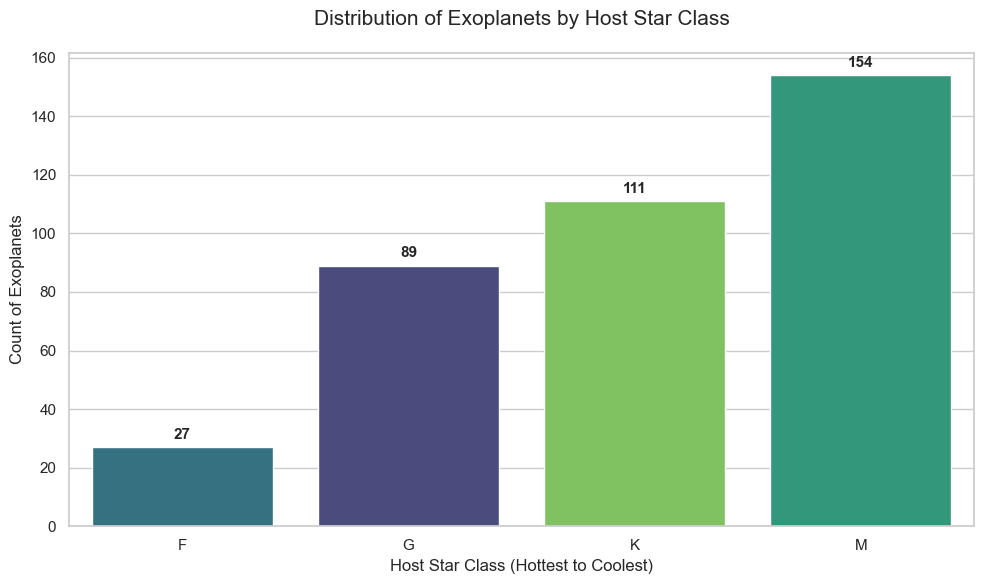

In [61]:
# Sets up the plot.
sns.set_theme(style = 'whitegrid')
plt.figure(figsize = (10, 6))

# Defines the order of stars from hottest (F) to coolest (M).
star_order = ['F', 'G', 'K', 'M']

ax = sns.countplot(
    data = planet_df,
    x = 'host_star_class',
    hue = 'host_star_class',
    order = star_order,
    palette = 'viridis',
    legend = False
)

plt.title('Distribution of Exoplanets by Host Star Class', fontsize = 15, pad = 20)
plt.xlabel('Host Star Class (Hottest to Coolest)', fontsize = 12)
plt.ylabel('Count of Exoplanets', fontsize = 12)

# Adds value labels on top of bars for clarity.
for p in ax.patches:
    height = p.get_height()
    
    if height > 0:
        ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize = 11,
                weight = 'bold')
    
plt.tight_layout()
plt.show()

**Interpretation:** This chart displays the distribution of the 381 filtered exoplanets across the stellar classes. 

There is a visible relation between the temperature of the host star and the number of exoplanets that orbit that class of star.

As we move from hottest host stars (F-type main sequence stars) to the cooler types (M-type red dwarfs), the number of observed exoplanets increases.

### Visualization 2: Correlation Heatmap of Planetary and Stellar Parameters

In [ ]:
// TODO: heatmap

**Interpretation:** TODO

### Visualization 3: Numerical Correlation Heatmap

In [ ]:
// TODO: heatmap

**Interpretation:** TODO

### Habitability by Star Type

In [ ]:
// TODO: stacker bar chart

TODO: Interpretative caption of visualization 4

### Discovery Timeline

In [ ]:
// TODO: Line chart

TODO: Interpretative caption of visualization 5

### Proximity vs. Temperature

In [ ]:
// scatter plot

TODO: Interpretative caption of visualization 6

## Summary of Initial Findings

TODo

## Hypothesis for Further Exploration

TODO